In [2]:
# Load the python package
import os
import dynetan
from dynetan.toolkit import *
from dynetan.viz import *
from dynetan.proctraj import *
from dynetan.gencor import *
from dynetan.contact import *

import sys, os
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import griddata
import seaborn as sb
from statistics import mean, stdev
from matplotlib import colors
from IPython.display import set_matplotlib_formats

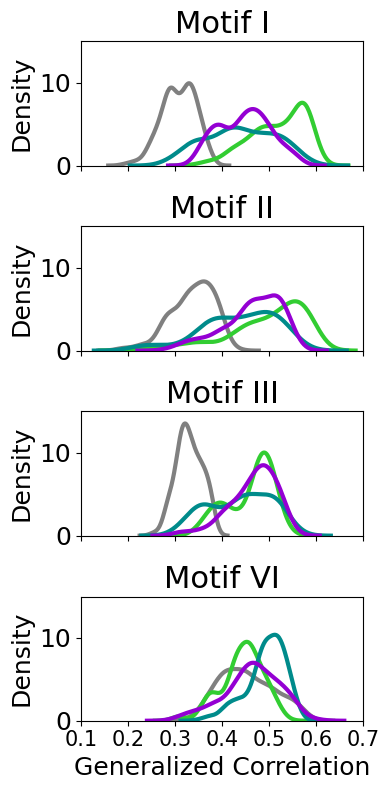

In [157]:
from scipy.stats import f_oneway
import numpy as np
from scipy.stats import kruskal
from scipy.stats import ttest_ind

source_dir="/home/usuario/ns3/qmmm/paper/md/"

motifs=[(14,23),(42,51),(135,139),(277,288)]
motifs_names=['Motif I','Motif II','Motif III','Motif VI']



all_dir = ["atp/", "rna7A/", "rna16A/"] #, "rna16A/clustering2/5endUp/", "rna16A/clustering2/5endDown/"]
# , "rna16A/"
workDir_atp = source_dir + "atp/" + "analisis/" 
workDir_rna7 = source_dir + "rna7A/" + "analisis/"
workDir_rna16 = source_dir + "rna16A/" + "analisis/"
workDir_rna16_up = source_dir + "rna16A/clustering2/5endUp/" + "analisis/"
workDir_rna16_down = source_dir + "rna16A/clustering2/5endDown/" + "analisis/"

pathToData_atp = workDir_atp+"Plots_GC/"
pathToData_rna7 = workDir_rna7+"Plots_GC/"
pathToData_rna16 = workDir_rna16+"Plots_GC/"
pathToData_rna16_up = workDir_rna16_up+"Plots_GC/"
pathToData_rna16_down = workDir_rna16_down+"Plots_GC/"

    
n2_R1_atp = np.load(workDir_atp+"GC_npArray.npy")
n2_R1_rna7 = np.load(workDir_rna7+"GC_npArray.npy")
n2_R1_rna16 = np.load(workDir_rna16+"GC_npArray.npy")
n2_R1_rna16_up = np.load(workDir_rna16_up+"GC_npArray2.npy")
n2_R1_rna16_down = np.load(workDir_rna16_down+"GC_npArray2.npy")


R1_atp = n2_R1_atp[0]
R1_rna7 = n2_R1_rna7[0]
R1_rna16 = n2_R1_rna16[0]
R1_rna16_up = n2_R1_rna16_up[0]
R1_rna16_down = n2_R1_rna16_down[0]

R1_rna7_prot = R1_rna7[:439,:439]
R1_rna16_prot = R1_rna16[:439,:439]
R1_rna16_prot_up = R1_rna16_up[:439,:439]
R1_rna16_prot_down = R1_rna16_down[:439,:439]

muchos_residuos=[]

# titulo= 'D2 (177-182)'
# titulo= 'D3 (357-365)'
# titulo= 'D3 (406-412)'
# titulo= 'D2 274'
# titulo= 'D1 (20-24)'

titulo= 'Pocket D3'
for i in range(528-180,555-179):
    muchos_residuos.append(i)

# titulo= 'Pocket RNA-D1'
# for i in range(290-180,308-179):
#     muchos_residuos.append(i)

# titulo= 'Pocket RNA-D1'
# for i in range(262-180,272-179):
#     muchos_residuos.append(i)

# titulo= 'Extra'
# for i in range(498-180,508-179):
#     muchos_residuos.append(i)



fig, axes = plt.subplots(4, 1, figsize=(4, 8), sharex=True, sharey=True)
# fig.suptitle(titulo, fontsize=16, y=1.02, ha='center')
t=0
for start,stop in motifs:
    regiones=[[],[],[],[],[]]
    for aa in muchos_residuos:
    # for aa in [64,99,101]:
        i=0
        for sistema in [R1_atp,R1_rna7_prot,R1_rna16_prot,R1_rna16_prot_up,R1_rna16_prot_down]:
            for j in range (start,stop):
                regiones[i].append(sistema[aa][j])
            i+=1
    
    # plt.figure(figsize=(8,6))
    
    sb.kdeplot(regiones[0], ax=axes[t], fill=False, alpha=1, linewidth=3, label='NS3h', color='gray',bw_adjust=1)
    sb.kdeplot(regiones[1], ax=axes[t], fill=False, alpha=1, linewidth=3, label='NS3h:RNA7', color='limegreen',bw_adjust=1)
    # sb.kdeplot(regiones[2], fill=True, alpha=0.6, linewidth=1.5, label='rna16',color='darkgreen')
    sb.kdeplot(regiones[2], ax=axes[t],fill=False, alpha=1, linewidth=3, label='NS3h:RNA16-D3', color='darkcyan',bw_adjust=1)
    sb.kdeplot(regiones[3], ax=axes[t],fill=False, alpha=1, linewidth=3, label='NS3h:RNA16-D2', color='darkviolet',bw_adjust=1)
    # stat, p_value = ttest_ind(regiones[0], regiones[1],equal_var=False)
    # axes[0].legend()
    # print(f"t-statistic: {stat:.4f}, p-value: {p_value:.4e}")
    # plt.xlim(0,1)
    # plt.title(titulo, fontsize=20)
    axes[t].set_title(motifs_names[t],fontsize=22)
    axes[t].set_ylabel('Density',fontsize=18)
    axes[t].tick_params(axis='y', labelsize=18)
    t+=1

plt.xticks(fontsize=15)
plt.xlim(0.1,0.7)
plt.ylim(0,15)
plt.xlabel('Generalized Correlation',fontsize=18)
# plt.ylabel('Denisty',fontsize=15)
plt.tight_layout()
# plt.subplots_adjust(top=0.98)

plt.savefig("/home/usuario/ns3/qmmm/paper/figuras/GC/D3_ok_pocket_atpcat.png", dpi=300)
plt.show()
plt.close()


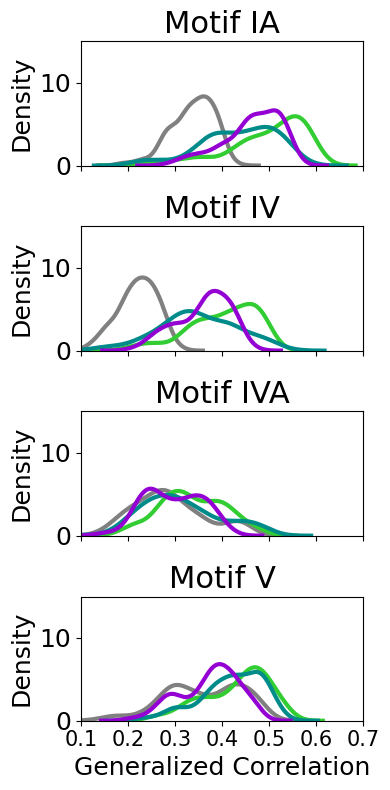

In [158]:
from scipy.stats import f_oneway
import numpy as np
from scipy.stats import kruskal
from scipy.stats import ttest_ind

source_dir="/home/usuario/ns3/qmmm/paper/md/"

motifs=[(42,51),(180,186),(204,211),(225,237)]
motifs_names=['Motif IA','Motif IV','Motif IVA','Motif V']



all_dir = ["atp/", "rna7A/", "rna16A/"] #, "rna16A/clustering2/5endUp/", "rna16A/clustering2/5endDown/"]
# , "rna16A/"
workDir_atp = source_dir + "atp/" + "analisis/" 
workDir_rna7 = source_dir + "rna7A/" + "analisis/"
workDir_rna16 = source_dir + "rna16A/" + "analisis/"
workDir_rna16_up = source_dir + "rna16A/clustering2/5endUp/" + "analisis/"
workDir_rna16_down = source_dir + "rna16A/clustering2/5endDown/" + "analisis/"

pathToData_atp = workDir_atp+"Plots_GC/"
pathToData_rna7 = workDir_rna7+"Plots_GC/"
pathToData_rna16 = workDir_rna16+"Plots_GC/"
pathToData_rna16_up = workDir_rna16_up+"Plots_GC/"
pathToData_rna16_down = workDir_rna16_down+"Plots_GC/"

    
n2_R1_atp = np.load(workDir_atp+"GC_npArray.npy")
n2_R1_rna7 = np.load(workDir_rna7+"GC_npArray.npy")
n2_R1_rna16 = np.load(workDir_rna16+"GC_npArray.npy")
n2_R1_rna16_up = np.load(workDir_rna16_up+"GC_npArray2.npy")
n2_R1_rna16_down = np.load(workDir_rna16_down+"GC_npArray2.npy")


R1_atp = n2_R1_atp[0]
R1_rna7 = n2_R1_rna7[0]
R1_rna16 = n2_R1_rna16[0]
R1_rna16_up = n2_R1_rna16_up[0]
R1_rna16_down = n2_R1_rna16_down[0]

R1_rna7_prot = R1_rna7[:439,:439]
R1_rna16_prot = R1_rna16[:439,:439]
R1_rna16_prot_up = R1_rna16_up[:439,:439]
R1_rna16_prot_down = R1_rna16_down[:439,:439]

muchos_residuos=[]

# titulo= 'D2 (177-182)'
# titulo= 'D3 (357-365)'
# titulo= 'D3 (406-412)'
# titulo= 'D2 274'
# titulo= 'D1 (20-24)'

titulo= 'Pocket D3'
for i in range(528-180,555-179):
    muchos_residuos.append(i)

# titulo= 'Pocket RNA-D1'
# for i in range(290-180,308-179):
#     muchos_residuos.append(i)

# titulo= 'Pocket RNA-D1'
# for i in range(262-180,272-179):
#     muchos_residuos.append(i)

# titulo= 'Extra'
# for i in range(498-180,508-179):
#     muchos_residuos.append(i)



fig, axes = plt.subplots(4, 1, figsize=(4, 8), sharex=True, sharey=True)
# fig.suptitle(titulo, fontsize=16, y=1.02, ha='center')
t=0
for start,stop in motifs:
    regiones=[[],[],[],[],[]]
    for aa in muchos_residuos:
    # for aa in [64,99,101]:
        i=0
        for sistema in [R1_atp,R1_rna7_prot,R1_rna16_prot,R1_rna16_prot_up,R1_rna16_prot_down]:
            for j in range (start,stop):
                regiones[i].append(sistema[aa][j])
            i+=1
    
    # plt.figure(figsize=(8,6))
    
    sb.kdeplot(regiones[0], ax=axes[t], fill=False, alpha=1, linewidth=3, label='NS3h', color='gray',bw_adjust=1)
    sb.kdeplot(regiones[1], ax=axes[t], fill=False, alpha=1, linewidth=3, label='NS3h:RNA7', color='limegreen',bw_adjust=1)
    # sb.kdeplot(regiones[2], fill=True, alpha=0.6, linewidth=1.5, label='rna16',color='darkgreen')
    sb.kdeplot(regiones[2], ax=axes[t],fill=False, alpha=1, linewidth=3, label='NS3h:RNA16-D3', color='darkcyan',bw_adjust=1)
    sb.kdeplot(regiones[3], ax=axes[t],fill=False, alpha=1, linewidth=3, label='NS3h:RNA16-D2', color='darkviolet',bw_adjust=1)
    # stat, p_value = ttest_ind(regiones[0], regiones[1],equal_var=False)
    # axes[0].legend()
    # print(f"t-statistic: {stat:.4f}, p-value: {p_value:.4e}")
    # plt.xlim(0,1)
    # plt.title(titulo, fontsize=20)
    axes[t].set_title(motifs_names[t], fontsize=22)
    axes[t].set_ylabel('Density',fontsize=18)
    axes[t].tick_params(axis='y', labelsize=18)
    t+=1

plt.xticks(fontsize=15)
plt.xlim(0.1,0.7)
plt.ylim(0,15)
plt.xlabel('Generalized Correlation',fontsize=18)
# plt.ylabel('Denisty',fontsize=15)
plt.tight_layout()
# plt.subplots_adjust(top=0.98)

plt.savefig("/home/usuario/ns3/qmmm/paper/figuras/GC/D3_ok_pocket.png", dpi=300)
plt.show()
plt.close()


1/5---------------------------------------------------------------------------------------------
/home/usuario/ns3/qmmm/paper/md/atp/analisis/
(439, 439)
/home/usuario/ns3/qmmm/paper/md/atp/analisis/Plots_GC/


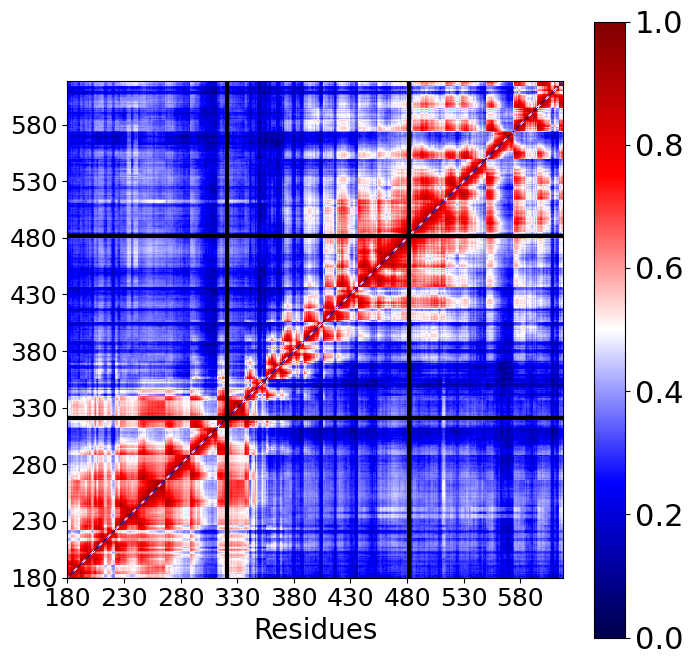

2/5---------------------------------------------------------------------------------------------
/home/usuario/ns3/qmmm/paper/md/rna7A/analisis/
(446, 446)
/home/usuario/ns3/qmmm/paper/md/rna7A/analisis/Plots_GC/


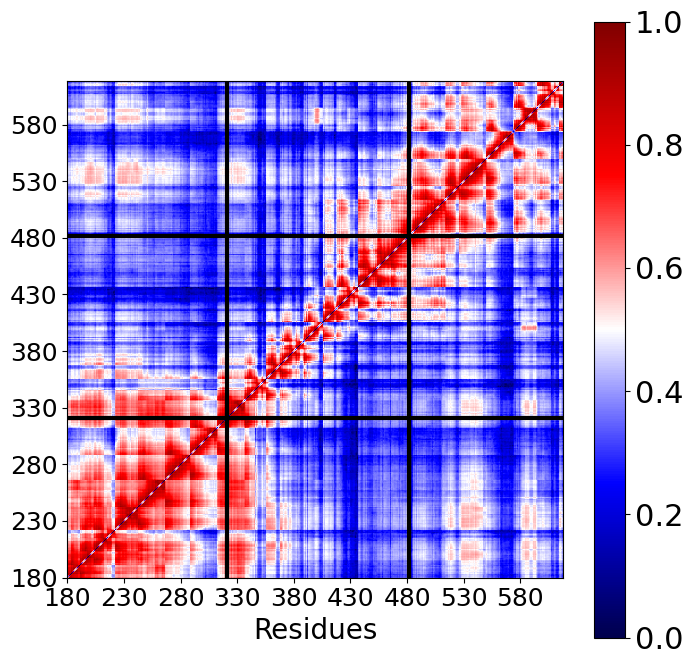

3/5---------------------------------------------------------------------------------------------
/home/usuario/ns3/qmmm/paper/md/rna16A/analisis/
(455, 455)
/home/usuario/ns3/qmmm/paper/md/rna16A/analisis/Plots_GC/


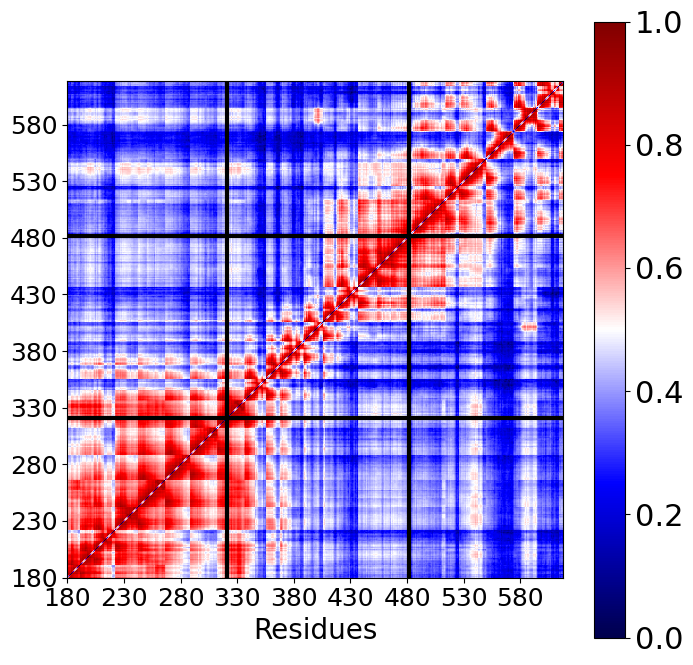

4/5---------------------------------------------------------------------------------------------
/home/usuario/ns3/qmmm/paper/md/rna16A/clustering2/5endUp/analisis/
(455, 455)
/home/usuario/ns3/qmmm/paper/md/rna16A/clustering2/5endUp/analisis/Plots_GC/


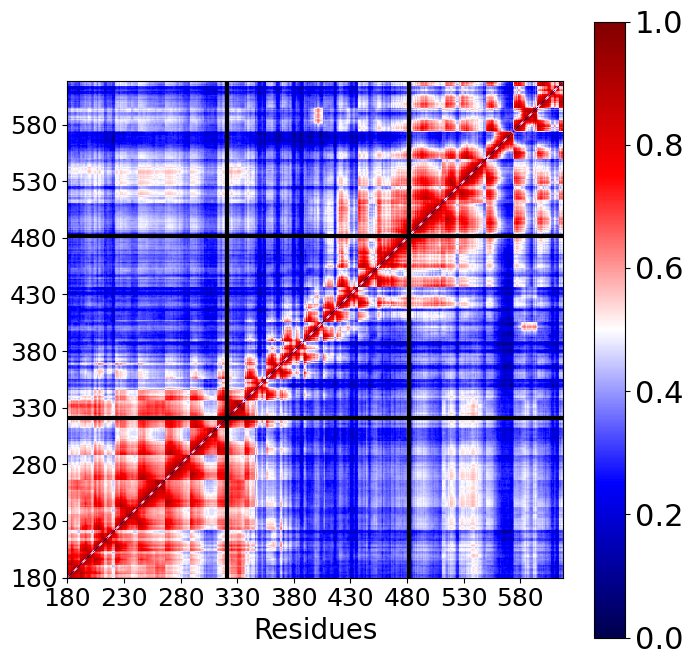

5/5---------------------------------------------------------------------------------------------
/home/usuario/ns3/qmmm/paper/md/rna16A/clustering2/5endDown/analisis/
(455, 455)
/home/usuario/ns3/qmmm/paper/md/rna16A/clustering2/5endDown/analisis/Plots_GC/


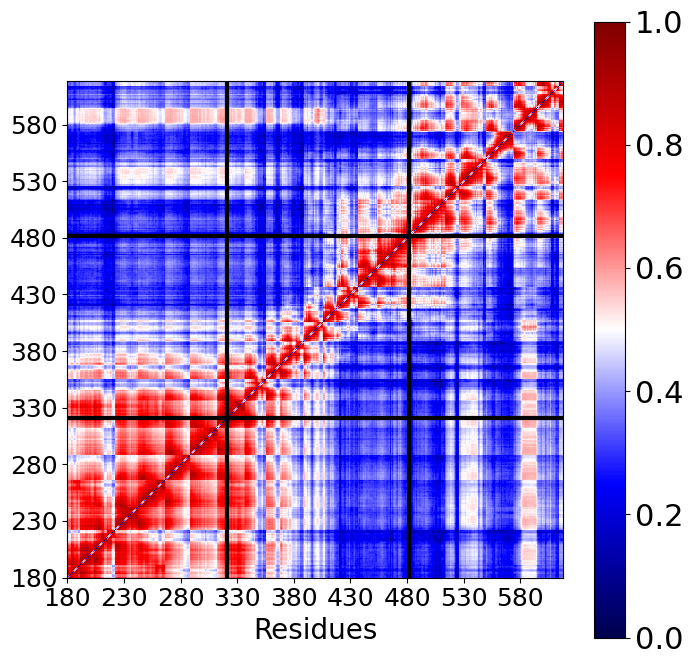

In [164]:
source_dir="/home/usuario/ns3/qmmm/paper/md/"

all_dir = ["atp/", "rna7A/","rna16A/", "rna16A/clustering2/5endUp/", "rna16A/clustering2/5endDown/"]
i=1

#mapaColor= 'RdYlBu''PRGn_r''PuOr''RdGy_r''seismic'
mapaColor='seismic'
for directory in all_dir:
    workDir = source_dir + directory + "analisis/" 
    
    if not os.path.exists(workDir):
        print('No existe' + workDir)
    else:
        print(str(i)+'/'+str(len(all_dir))+'---------------------------------------------------------------------------------------------')
        print(workDir)
    i+=1
    
    pathToData = workDir+"Plots_GC/"
    
    if not os.path.isdir(pathToData):
        os.mkdir(pathToData)

    # Load the saved GC matrix as a np array
    # Path where input files will searched and results be written.

    if '5' in directory:
        nameFileGC = "GC_npArray2.npy"
    else:
        nameFileGC = "GC_npArray.npy"
        
    n2_R1 = np.load(workDir+nameFileGC)
    
    R1 = n2_R1[0] ## cluster0 - 1 window analysis
    print(R1.shape)
    # size_matrix = R1.shape[0]
    size_matrix = 438

    plt.figure(figsize=(8,8))
    #2D matrix
    plt.imshow(R1, cmap = mapaColor, vmin = 0, vmax = 1)
    
    plt.axis([0,size_matrix, 0, size_matrix])
    
    # Vertical Lines
    plt.plot([141, 141], [0, size_matrix], 'k', lw=3.0)
    plt.plot([302, 302], [0, size_matrix], 'k', lw=3.0)
    # plt.plot([438, 438], [0, size_matrix], 'k', lw=1.0)
    
    # Horizontal lines
    plt.plot([0, size_matrix], [141, 141], 'k', lw=3.0)
    plt.plot([0, size_matrix], [302, 302], 'k', lw=3.0)
    # plt.plot([0, size_matrix], [438, 438], 'k', lw=1.0)
    
    # if 'rna' in workDir:
    #     plt.plot([887, 887], [0, size_matrix], 'k', lw=1.0)
    #     plt.plot([0, size_matrix], [887, 887], 'k', lw=1.0)

    plt.xticks(np.arange(0, 438, step=50), np.arange(180, 618, step=50),fontsize = 18)
    plt.yticks(np.arange(0, 438, step=50), np.arange(180, 618, step=50),fontsize = 18)
    
    
    plt.xlabel('Residues',  fontsize = 20)
    plt.ylabel('', fontsize = 18)
    # plt.xticks(fontsize = 18)
    # plt.yticks(fontsize = 18)
    cbar = plt.colorbar(location='right')
    for t in cbar.ax.get_yticklabels():
         t.set_fontsize(22)
    print(pathToData)
    plt.savefig(pathToData+"GC_ok", dpi=300)
    plt.show()
    plt.close()
    

(439, 439)
(446, 446)
rna7A/


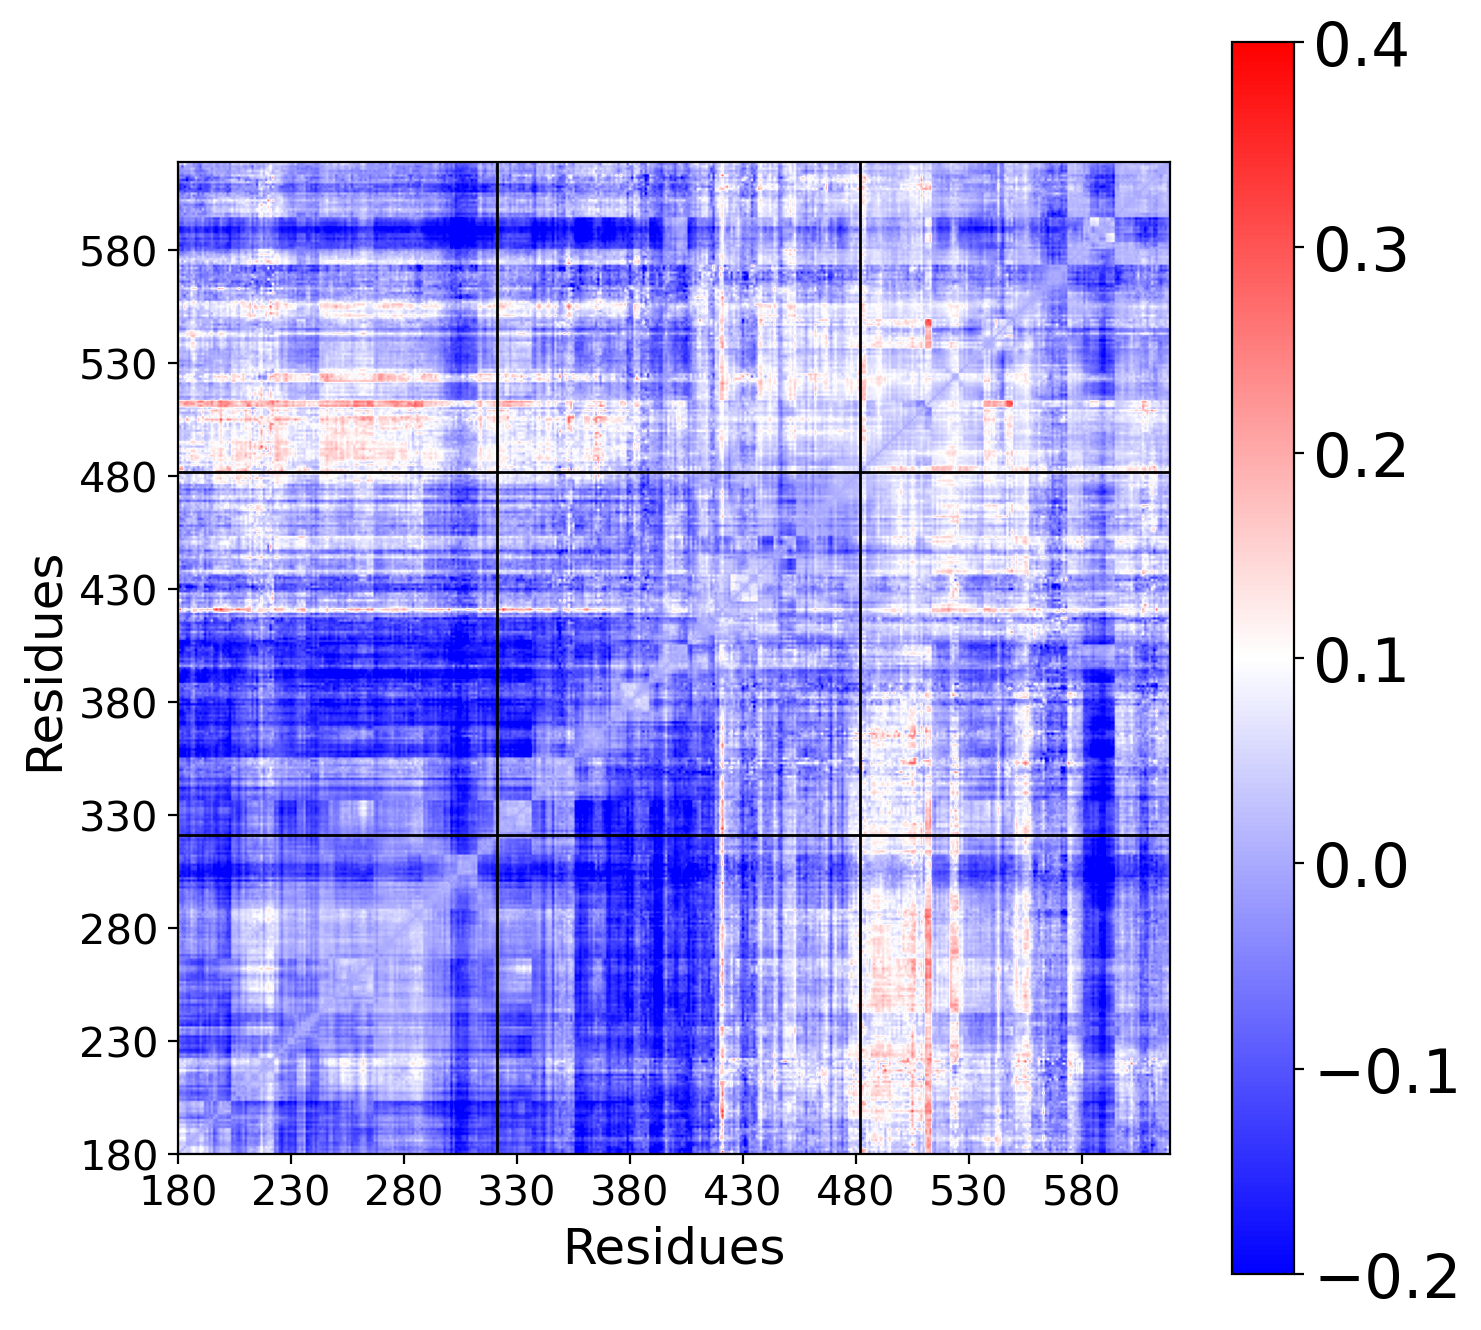

In [8]:
source_dir="/home/usuario/ns3/qmmm/paper/md/"

all_dir = ["atp/", "rna7A/", "rna16A/", "rna16A/clustering2/5endUp", "rna16A/clustering2/5endDown"]
d=1

workDir_atp = source_dir + "atp/" + "analisis/" 
workDir_rna7 = source_dir + "rna7A/" + "analisis/"
workDir_rna16 = source_dir + "rna16A/" + "analisis/"
workDir_rna16_up = source_dir + "rna16A/clustering2/5endUp/" + "analisis/"
workDir_rna16_down = source_dir + "rna16A/clustering2/5endDown/" + "analisis/"

pathToData_atp = workDir_atp+"Plots_GC/"
pathToData_rna7 = workDir_rna7+"Plots_GC/"
pathToData_rna16 = workDir_rna16+"Plots_GC/"
pathToData_rna16_up = workDir_rna16_up+"Plots_GC/"
pathToData_rna16_down = workDir_rna16_down+"Plots_GC/"

nameFileGC = "GC_npArray.npy"
    
n2_R1_atp = np.load(workDir_atp+nameFileGC)
n2_R1_rna7 = np.load(workDir_rna7+nameFileGC)
n2_R1_rna16 = np.load(workDir_rna16+nameFileGC)
n2_R1_rna16_up = np.load(workDir_rna16_up+nameFileGC)
n2_R1_rna16_down = np.load(workDir_rna16_down+nameFileGC)
    
R1_atp = n2_R1_atp[0]
R1_rna7 = n2_R1_rna7[0]
R1_rna16 = n2_R1_rna16[0]
R1_rna16_up = n2_R1_rna16_up[0]
R1_rna16_down = n2_R1_rna16_down[0]

print(R1_atp.shape)
print(R1_rna7.shape)

R1_rna7_prot = R1_rna7[:439,:439]
R1_rna16_prot = R1_rna16[:439,:439]
R1_rna16_prot_up = R1_rna16_up[:439,:439]
R1_rna16_prot_down = R1_rna16_down[:439,:439]

dif_rna7 = R1_rna7_prot - R1_atp
dif_rna16 = R1_rna16_prot - R1_atp
dif_rna16_up = R1_rna16_prot_up - R1_atp
dif_rna16_down = R1_rna16_prot_down - R1_atp
dif_up_down = R1_rna16_prot_up - R1_rna16_prot_down

i=7
# for system in [dif_rna7, dif_rna16, dif_rna16_up, dif_rna16_down]:
for system in [dif_up_down]:
    print(all_dir[d])
    d+=1
    size_matrix = 439

    plt.figure(figsize=(8,8))
    #2D matrix
    plt.imshow(system, cmap = 'bwr', vmin = -0.2, vmax = 0.4)
    
    plt.axis([0,size_matrix, 0, size_matrix])
    
    # Vertical Lines
    plt.plot([141, 141], [0, size_matrix], 'k', lw=1.0)
    plt.plot([302, 302], [0, size_matrix], 'k', lw=1.0)
    
    # Horizontal lines
    plt.plot([0, size_matrix], [141, 141], 'k', lw=1.0)
    plt.plot([0, size_matrix], [302, 302], 'k', lw=1.0)
        
    plt.xlabel('Residues',  fontsize = 18)
    plt.ylabel('Residues', fontsize = 18)

    plt.xticks(np.arange(0, 438, step=50), np.arange(180, 618, step=50),fontsize = 15)
    plt.yticks(np.arange(0, 438, step=50), np.arange(180, 618, step=50),fontsize = 15)
    cbar = plt.colorbar()
    for t in cbar.ax.get_yticklabels():
         t.set_fontsize(22)
    
    # plt.savefig("/home/usuario/ns3/qmmm/paper/figuras/GC_dif"+str(i)+".png", dpi=300) 
    i=i+9
    
    plt.show()
    plt.close()
